In [76]:
import duckdb
import pandas as pd
from pathlib import Path

# reads in the statcast data from the database for 2025 season

db_path = Path("~/repos/statcast-database/statcast.duckdb").expanduser()

conn = duckdb.connect(str(db_path))
df = conn.execute("""
    SELECT
        game_pk,
        game_date,
        inning,
        inning_topbot,
        at_bat_number,
        pitch_number,
        pitcher,
        player_name,
        home_team,
        away_team,
        events,
        woba_value,
        woba_denom,
        estimated_woba_using_speedangle
    FROM statcast
    WHERE game_date >= '2025-03-27'
      AND game_date <= '2025-11-30'
    ORDER BY game_pk, at_bat_number, pitch_number
""").df()

df.head()

,game_pk,game_date,inning,inning_topbot,at_bat_number,pitch_number,pitcher,player_name,home_team,away_team,events,woba_value,woba_denom,estimated_woba_using_speedangle
0,776135,2025-09-28,1,Top,1,1,691951,"Aldegheri, Sam",LAA,HOU,NaN,NaN,<NA>,NaN
1,776135,2025-09-28,1,Top,1,2,691951,"Aldegheri, Sam",LAA,HOU,NaN,NaN,<NA>,NaN
2,776135,2025-09-28,1,Top,1,3,691951,"Aldegheri, Sam",LAA,HOU,NaN,NaN,<NA>,NaN
3,776135,2025-09-28,1,Top,1,4,691951,"Aldegheri, Sam",LAA,HOU,NaN,NaN,<NA>,NaN
4,776135,2025-09-28,1,Top,1,5,691951,"Aldegheri, Sam",LAA,HOU,NaN,NaN,<NA>,NaN


In [77]:
# designates the pitching team based on the top or the bottom half of the inning

df["pitching_team"] = df["home_team"].where(
    df["inning_topbot"] == "Top",
    df["away_team"]
)
df.head()

,game_pk,game_date,inning,inning_topbot,at_bat_number,pitch_number,pitcher,player_name,home_team,away_team,events,woba_value,woba_denom,estimated_woba_using_speedangle,pitching_team
0,776135,2025-09-28,1,Top,1,1,691951,"Aldegheri, Sam",LAA,HOU,NaN,NaN,<NA>,NaN,LAA
1,776135,2025-09-28,1,Top,1,2,691951,"Aldegheri, Sam",LAA,HOU,NaN,NaN,<NA>,NaN,LAA
2,776135,2025-09-28,1,Top,1,3,691951,"Aldegheri, Sam",LAA,HOU,NaN,NaN,<NA>,NaN,LAA
3,776135,2025-09-28,1,Top,1,4,691951,"Aldegheri, Sam",LAA,HOU,NaN,NaN,<NA>,NaN,LAA
4,776135,2025-09-28,1,Top,1,5,691951,"Aldegheri, Sam",LAA,HOU,NaN,NaN,<NA>,NaN,LAA


In [78]:

# then groups by the gameID(pk), game_date, pitching_team, pitcherID, and player_name
# it then aggregates globally the pitchers first AB number in the game, last, and the nunmber of pitches

appearances = (
    df.groupby(
        ["game_pk", "game_date", "pitching_team", "pitcher", "player_name"],
        as_index=False
    )
    .agg(
        first_ab=("at_bat_number", "min"),
        last_ab=("at_bat_number", "max"),
        pitches=("pitch_number", "size")
    )
)

In [79]:
appearances

,game_pk,game_date,pitching_team,pitcher,player_name,first_ab,last_ab,pitches
0,776135,2025-09-28,HOU,621121,"McCullers Jr., Lance",8,30,54
1,776135,2025-09-28,HOU,676467,"Gordon, Colton",34,70,68
2,776135,2025-09-28,HOU,681151,"Murray, Jayden",74,80,24
3,776135,2025-09-28,LAA,641401,"Brogdon, Connor",42,51,27
4,776135,2025-09-28,LAA,666171,"Zeferjahn, Ryan",56,60,21
...,...,...,...,...,...,...,...,...
21318,813074,2025-09-30,NYY,596133,"Weaver, Luke",46,48,15
21319,813074,2025-09-30,NYY,608331,"Fried, Max",1,45,102
21320,813074,2025-09-30,NYY,642207,"Williams, Devin",55,58,11
21321,813074,2025-09-30,NYY,657612,"Hill, Tim",67,67,4


In [80]:
# just sorts the df by the player who entered the game first so that we can later add previous pitcher

appearances = appearances.sort_values(
    ["game_pk", "pitching_team", "first_ab"]
)
appearances.head()

,game_pk,game_date,pitching_team,pitcher,player_name,first_ab,last_ab,pitches
0,776135,2025-09-28,HOU,621121,"McCullers Jr., Lance",8,30,54
1,776135,2025-09-28,HOU,676467,"Gordon, Colton",34,70,68
2,776135,2025-09-28,HOU,681151,"Murray, Jayden",74,80,24
6,776135,2025-09-28,LAA,691951,"Aldegheri, Sam",1,41,96
3,776135,2025-09-28,LAA,641401,"Brogdon, Connor",42,51,27


In [81]:
# groups by game and pitching team and then shifts the previous pitcher value down 1 as the previous pitcher

appearances["previous_pitcher"] = (
    appearances
    .groupby(["game_pk", "pitching_team"])["pitcher"]
    .shift(1)
)

appearances["previous_pitcher_name"] = (
    appearances
    .groupby(["game_pk", "pitching_team"])["player_name"]
    .shift(1)
)

appearances.head()

,game_pk,game_date,pitching_team,pitcher,player_name,first_ab,last_ab,pitches,previous_pitcher,previous_pitcher_name
0,776135,2025-09-28,HOU,621121,"McCullers Jr., Lance",8,30,54,NaN,NaN
1,776135,2025-09-28,HOU,676467,"Gordon, Colton",34,70,68,621121.0,"McCullers Jr., Lance"
2,776135,2025-09-28,HOU,681151,"Murray, Jayden",74,80,24,676467.0,"Gordon, Colton"
6,776135,2025-09-28,LAA,691951,"Aldegheri, Sam",1,41,96,NaN,NaN
3,776135,2025-09-28,LAA,641401,"Brogdon, Connor",42,51,27,691951.0,"Aldegheri, Sam"


In [82]:
# groups by game, pitching_team, and pitcher and then gets unique AB #'s 
# to determine the amount of at bats a pitcher has thrown the pitch that results in the final outcome
# filtered out events that were truncated_pa like caught stealing, pick off

completed_pa = df[
    df["events"].notna() &
    (df["events"] != "truncated_pa")
].copy()

pa_counts = (
    completed_pa
    .groupby(["game_pk", "pitching_team", "pitcher"])
    .size()
    .reset_index(name="completed_pa")
)

appearances = appearances.merge(
    pa_counts,
    on=["game_pk", "pitching_team", "pitcher"],
    how="left"
)

appearances["completed_pa"] = appearances["completed_pa"].fillna(0).astype(int)


In [83]:
appearances.head()

,game_pk,game_date,pitching_team,pitcher,player_name,first_ab,last_ab,pitches,previous_pitcher,previous_pitcher_name,completed_pa
0,776135,2025-09-28,HOU,621121,"McCullers Jr., Lance",8,30,54,NaN,NaN,13
1,776135,2025-09-28,HOU,676467,"Gordon, Colton",34,70,68,621121.0,"McCullers Jr., Lance",16
2,776135,2025-09-28,HOU,681151,"Murray, Jayden",74,80,24,676467.0,"Gordon, Colton",7
3,776135,2025-09-28,LAA,691951,"Aldegheri, Sam",1,41,96,NaN,NaN,25
4,776135,2025-09-28,LAA,641401,"Brogdon, Connor",42,51,27,691951.0,"Aldegheri, Sam",6


In [84]:
# we can see that there are no xwoba values for catcher_interf and there are some missing for doubles, etc.

completed_pa[
    [
        "events",
        "estimated_woba_using_speedangle",
        "woba_value",
        "woba_denom"
    ]
].groupby("events").agg(
    n=("events", "size"),
    xwoba_non_null=("estimated_woba_using_speedangle", "count"),
    woba_non_null=("woba_value", "count"),
    woba_denom_non_null=("woba_denom", "count")
)

,n,xwoba_non_null,woba_non_null,woba_denom_non_null
events,,,,
catcher_interf,86,0,86,86
double,7875,7870,7875,7870
double_play,385,385,385,385
field_error,1029,1021,1029,1021
field_out,75693,75374,75693,75374
fielders_choice,393,390,393,390
fielders_choice_out,334,333,334,333
force_out,3426,3406,3426,3406
grounded_into_double_play,3164,3145,3164,3145


In [85]:
completed_pa[
    completed_pa["estimated_woba_using_speedangle"].isna()
][
    [
        "events",
        "woba_value",
        "woba_denom",
        "estimated_woba_using_speedangle"
    ]
].value_counts(dropna=False)

events                     woba_value  woba_denom  estimated_woba_using_speedangle
intent_walk                0.40        0           NaN                                594
sac_bunt                   0.20        0           NaN                                515
field_out                  0.00        <NA>        NaN                                319
catcher_interf             0.70        1           NaN                                 86
single                     0.90        <NA>        NaN                                 67
sac_bunt                   0.90        0           NaN                                 56
force_out                  0.00        <NA>        NaN                                 20
grounded_into_double_play  0.00        <NA>        NaN                                 19
sac_bunt                   0.20        <NA>        NaN                                 11
field_error                0.90        <NA>        NaN                                  8
double           

In [86]:
# xwoba_pa is just the plate appearances where there is a valid xwoba

xwoba_pa = completed_pa[
    completed_pa["estimated_woba_using_speedangle"].notna()
].copy()

xwoba_pa["pa_xwoba"] = xwoba_pa[
    "estimated_woba_using_speedangle"
]

In [87]:
# appearance_xwoba is then just the sum(xwoba for every PA) / plate appearances where there is a valid xwoba
# sum(pa_xwoba)/xwoba_pa

appearance_xwoba = (
    xwoba_pa
    .groupby(["game_pk", "pitching_team", "pitcher"])
    .agg(
        appearance_xwoba=("pa_xwoba", "mean"),
        xwoba_pa=("pa_xwoba", "size")
    )
    .reset_index()
)

In [88]:
appearances = appearances.merge(
    appearance_xwoba,
    on=["game_pk", "pitching_team", "pitcher"],
    how="left"
)

In [89]:
appearances

,game_pk,game_date,pitching_team,pitcher,player_name,first_ab,last_ab,pitches,previous_pitcher,previous_pitcher_name,completed_pa,appearance_xwoba,xwoba_pa
0,776135,2025-09-28,HOU,621121,"McCullers Jr., Lance",8,30,54,NaN,NaN,13,0.393269,13.0
1,776135,2025-09-28,HOU,676467,"Gordon, Colton",34,70,68,621121.0,"McCullers Jr., Lance",16,0.202785,16.0
2,776135,2025-09-28,HOU,681151,"Murray, Jayden",74,80,24,676467.0,"Gordon, Colton",7,0.355000,7.0
3,776135,2025-09-28,LAA,691951,"Aldegheri, Sam",1,41,96,NaN,NaN,25,0.407000,25.0
4,776135,2025-09-28,LAA,641401,"Brogdon, Connor",42,51,27,691951.0,"Aldegheri, Sam",6,0.558248,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21318,813074,2025-09-30,NYY,596133,"Weaver, Luke",46,48,15,608331.0,"Fried, Max",3,0.603499,3.0
21319,813074,2025-09-30,NYY,518585,"Cruz, Fernando",49,51,14,596133.0,"Weaver, Luke",3,0.366166,3.0
21320,813074,2025-09-30,NYY,642207,"Williams, Devin",55,58,11,518585.0,"Cruz, Fernando",4,0.216124,4.0
21321,813074,2025-09-30,NYY,670280,"Bednar, David",63,66,15,642207.0,"Williams, Devin",4,0.297250,4.0


In [90]:
#this puts the pitcher and previous pitcher in the xwoba_pa outcome df
xwoba_pa = xwoba_pa.merge(
    appearances[
        ["game_pk", "pitching_team", "pitcher", "previous_pitcher", "previous_pitcher_name"]
    ],
    on=["game_pk", "pitching_team", "pitcher"],
    how="left"
)

In [91]:
xwoba_pa

,game_pk,game_date,inning,inning_topbot,at_bat_number,pitch_number,pitcher,player_name,home_team,away_team,events,woba_value,woba_denom,estimated_woba_using_speedangle,pitching_team,pa_xwoba,previous_pitcher,previous_pitcher_name
0,776135,2025-09-28,1,Top,1,6,691951,"Aldegheri, Sam",LAA,HOU,strikeout,0.0,1,0.000000,LAA,0.000000,NaN,NaN
1,776135,2025-09-28,1,Top,2,3,691951,"Aldegheri, Sam",LAA,HOU,single,0.9,1,0.464000,LAA,0.464000,NaN,NaN
2,776135,2025-09-28,1,Top,3,3,691951,"Aldegheri, Sam",LAA,HOU,hit_by_pitch,0.7,1,0.722289,LAA,0.722289,NaN,NaN
3,776135,2025-09-28,1,Top,4,1,691951,"Aldegheri, Sam",LAA,HOU,single,0.9,1,0.461000,LAA,0.461000,NaN,NaN
4,776135,2025-09-28,1,Top,5,6,691951,"Aldegheri, Sam",LAA,HOU,strikeout,0.0,1,0.000000,LAA,0.000000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184695,813074,2025-09-30,9,Bot,69,1,547973,"Chapman, Aroldis",NYY,BOS,single,0.9,1,0.653000,BOS,0.653000,676979.0,"Crochet, Garrett"
184696,813074,2025-09-30,9,Bot,70,1,547973,"Chapman, Aroldis",NYY,BOS,single,0.9,1,0.138000,BOS,0.138000,676979.0,"Crochet, Garrett"
184697,813074,2025-09-30,9,Bot,71,4,547973,"Chapman, Aroldis",NYY,BOS,strikeout,0.0,1,0.000000,BOS,0.000000,676979.0,"Crochet, Garrett"
184698,813074,2025-09-30,9,Bot,72,4,547973,"Chapman, Aroldis",NYY,BOS,field_out,0.0,1,0.019000,BOS,0.019000,676979.0,"Crochet, Garrett"


In [99]:
# this gets the pitcher_pairs and is the pitcher's xwoba after pitching for the previous pitcher

pitcher_pairs = (
    xwoba_pa
    .groupby(
        ["previous_pitcher", "pitcher"],
        dropna=False
    )
    .agg(
        xwoba_sum=("pa_xwoba", "sum"),
        xwoba_pa=("pa_xwoba", "size"),
        appearances=("game_pk", "nunique")
    )
    .reset_index()
)

pitcher_pairs["pair_xwoba"] = (
    pitcher_pairs["xwoba_sum"] /
    pitcher_pairs["xwoba_pa"]
)

In [100]:
pitcher_pairs

,previous_pitcher,pitcher,xwoba_sum,xwoba_pa,appearances,pair_xwoba
0,434378.0,642152,0.691497,2,1,0.345749
1,434378.0,657424,1.149289,5,1,0.229858
2,434378.0,663546,0.646000,3,1,0.215333
3,434378.0,663941,5.837497,24,2,0.243229
4,434378.0,664192,5.804939,26,6,0.223267
...,...,...,...,...,...,...
7064,NaN,808963,52.462302,139,7,0.377427
7065,NaN,808967,208.429169,794,34,0.262505
7066,NaN,813349,23.426244,98,5,0.239043
7067,NaN,815083,38.242821,106,5,0.360781


In [101]:
pitcher_pairs['xwoba_pa'].sum()

np.int64(184700)

In [104]:
# get totals for each pitcher

pitcher_totals = (
    pitcher_pairs
    .groupby("pitcher")
    .agg(
        total_xwoba_sum=("xwoba_sum", "sum"),
        total_xwoba_pa=("xwoba_pa", "sum")
    )
    .reset_index()
)

In [105]:
pitcher_totals

,pitcher,total_xwoba_sum,total_xwoba_pa
0,434378,209.858599,658
1,445276,69.463151,231
2,445926,16.468177,43
3,448179,16.832006,43
4,450203,214.841050,646
...,...,...,...
868,808967,211.313318,803
869,813349,23.426244,98
870,815083,38.242821,106
871,820862,47.084814,150


In [106]:
# merge the totals for each pitcher

pitcher_pairs = pitcher_pairs.merge(
    pitcher_totals,
    on="pitcher",
    how="left"
)

In [107]:
pitcher_pairs

,previous_pitcher,pitcher,xwoba_sum,xwoba_pa,appearances,pair_xwoba,total_xwoba_sum,total_xwoba_pa
0,434378.0,642152,0.691497,2,1,0.345749,70.648867,204
1,434378.0,657424,1.149289,5,1,0.229858,36.673295,135
2,434378.0,663546,0.646000,3,1,0.215333,24.345556,69
3,434378.0,663941,5.837497,24,2,0.243229,75.266312,231
4,434378.0,664192,5.804939,26,6,0.223267,47.492434,162
...,...,...,...,...,...,...,...,...
7064,NaN,808963,52.462302,139,7,0.377427,66.748805,188
7065,NaN,808967,208.429169,794,34,0.262505,211.313318,803
7066,NaN,813349,23.426244,98,5,0.239043,23.426244,98
7067,NaN,815083,38.242821,106,5,0.360781,38.242821,106


In [108]:
# get the xwoba for the pitcher outside of this pair

pitcher_pairs["other_xwoba"] = (
    (pitcher_pairs["total_xwoba_sum"] - pitcher_pairs["xwoba_sum"])
    /
    (pitcher_pairs["total_xwoba_pa"] - pitcher_pairs["xwoba_pa"])
)

In [109]:
pitcher_pairs

,previous_pitcher,pitcher,xwoba_sum,xwoba_pa,appearances,pair_xwoba,total_xwoba_sum,total_xwoba_pa,other_xwoba
0,434378.0,642152,0.691497,2,1,0.345749,70.648867,204,0.346324
1,434378.0,657424,1.149289,5,1,0.229858,36.673295,135,0.273262
2,434378.0,663546,0.646000,3,1,0.215333,24.345556,69,0.359084
3,434378.0,663941,5.837497,24,2,0.243229,75.266312,231,0.335405
4,434378.0,664192,5.804939,26,6,0.223267,47.492434,162,0.306526
...,...,...,...,...,...,...,...,...,...
7064,NaN,808963,52.462302,139,7,0.377427,66.748805,188,0.291561
7065,NaN,808967,208.429169,794,34,0.262505,211.313318,803,0.320461
7066,NaN,813349,23.426244,98,5,0.239043,23.426244,98,NaN
7067,NaN,815083,38.242821,106,5,0.360781,38.242821,106,NaN


In [110]:
pitcher_names = (
    appearances[["pitcher", "player_name"]]
    .drop_duplicates())

pitcher_pairs = pitcher_pairs.merge(
    pitcher_names,
    on="pitcher",
    how="left"
)

previous_pitcher_names = pitcher_names.rename(
    columns={
        "pitcher": "previous_pitcher",
        "player_name": "previous_pitcher_name"
    }
)

pitcher_pairs = pitcher_pairs.merge(
    previous_pitcher_names,
    on="previous_pitcher",
    how="left"
)

In [111]:
pitcher_pairs

,previous_pitcher,pitcher,xwoba_sum,xwoba_pa,appearances,pair_xwoba,total_xwoba_sum,total_xwoba_pa,other_xwoba,player_name,previous_pitcher_name
0,434378.0,642152,0.691497,2,1,0.345749,70.648867,204,0.346324,"Trivino III, Lou","Verlander, Justin"
1,434378.0,657424,1.149289,5,1,0.229858,36.673295,135,0.273262,"Gage, Matt","Verlander, Justin"
2,434378.0,663546,0.646000,3,1,0.215333,24.345556,69,0.359084,"Hjelle, Sean","Verlander, Justin"
3,434378.0,663941,5.837497,24,2,0.243229,75.266312,231,0.335405,"Beck, Tristan","Verlander, Justin"
4,434378.0,664192,5.804939,26,6,0.223267,47.492434,162,0.306526,"Lucchesi, Joey","Verlander, Justin"
...,...,...,...,...,...,...,...,...,...,...,...
7064,NaN,808963,52.462302,139,7,0.377427,66.748805,188,0.291561,"Sasaki, Roki",NaN
7065,NaN,808967,208.429169,794,34,0.262505,211.313318,803,0.320461,"Yamamoto, Yoshinobu",NaN
7066,NaN,813349,23.426244,98,5,0.239043,23.426244,98,NaN,"Early, Connelly",NaN
7067,NaN,815083,38.242821,106,5,0.360781,38.242821,106,NaN,"Farris, Mitch",NaN


In [ ]:
# dropping the rows for pitchers who were only starters 
# they will still be included as a previous pitcher,
# but there is no interest in how the previous pitcher helped them
# because there was none

pure_starters = (
    pitcher_pairs["previous_pitcher"].isna()
    & (pitcher_pairs["xwoba_pa"] == pitcher_pairs["total_xwoba_pa"])
)

pitcher_pairs = pitcher_pairs.loc[~pure_starters].copy()

pitcher_pairs["xwoba_diff"] = (
    pitcher_pairs["pair_xwoba"] - pitcher_pairs["other_xwoba"]
)

In [114]:
pitcher_pairs

,previous_pitcher,pitcher,xwoba_sum,xwoba_pa,appearances,pair_xwoba,total_xwoba_sum,total_xwoba_pa,other_xwoba,player_name,previous_pitcher_name,xwoba_diff
0,434378.0,642152,0.691497,2,1,0.345749,70.648867,204,0.346324,"Trivino III, Lou","Verlander, Justin",-0.000575
1,434378.0,657424,1.149289,5,1,0.229858,36.673295,135,0.273262,"Gage, Matt","Verlander, Justin",-0.043404
2,434378.0,663546,0.646000,3,1,0.215333,24.345556,69,0.359084,"Hjelle, Sean","Verlander, Justin",-0.143751
3,434378.0,663941,5.837497,24,2,0.243229,75.266312,231,0.335405,"Beck, Tristan","Verlander, Justin",-0.092176
4,434378.0,664192,5.804939,26,6,0.223267,47.492434,162,0.306526,"Lucchesi, Joey","Verlander, Justin",-0.083259
...,...,...,...,...,...,...,...,...,...,...,...,...
7062,NaN,806188,1.553497,4,1,0.388374,68.745275,226,0.302666,"Gibson, Cade",NaN,0.085709
7063,NaN,806960,60.853266,189,9,0.321975,64.411763,198,0.395389,"Morales, Luis",NaN,-0.073414
7064,NaN,808963,52.462302,139,7,0.377427,66.748805,188,0.291561,"Sasaki, Roki",NaN,0.085865
7065,NaN,808967,208.429169,794,34,0.262505,211.313318,803,0.320461,"Yamamoto, Yoshinobu",NaN,-0.057956


In [120]:
pitcher_pairs.sort_values(by = 'xwoba_diff').head(20)

,previous_pitcher,pitcher,xwoba_sum,xwoba_pa,appearances,pair_xwoba,total_xwoba_sum,total_xwoba_pa,other_xwoba,player_name,previous_pitcher_name,xwoba_diff
4415,673540.0,692024,1.530,8,1,0.191250,11.568171,22,0.717012,"Carrillo, Alex","Senga, Kodai",-0.525762
6572,801216.0,656257,0.000,1,1,0.000000,8.573497,18,0.504323,"Brigham, Jeff","Montes De Oca, Christian",-0.504323
179,518489.0,605242,0.034,3,1,0.011333,10.341930,23,0.515396,"Fulmer, Michael","Brasier, Ryan",-0.504063
4280,671922.0,689958,0.591,4,1,0.147750,1.834889,6,0.621944,"Walters, Andrew","Smith, Cade",-0.474194
1311,608334.0,621028,0.258,3,1,0.086000,6.980746,16,0.517134,"Newman, Kevin","Fulmer, Carson",-0.431134
4099,670036.0,680951,0.231,3,1,0.077000,9.879564,23,0.482428,"Nikhazy, Doug","Festa, Matt",-0.405428
1432,620454.0,621057,0.000,2,1,0.000000,10.490743,28,0.403490,"Garza, Justin","Castillo, José",-0.403490
2348,656271.0,690829,0.195,4,1,0.048750,7.862054,21,0.451003,"Joyce, Ben","Burke, Brock",-0.402253
5103,680732.0,682171,0.000,3,1,0.000000,23.551410,62,0.399176,"Murfee, Penn","Burke, Sean",-0.399176
1155,606303.0,641343,0.127,3,1,0.042333,11.561979,29,0.439807,"Bauers, Jake","Payamps, Joel",-0.397474


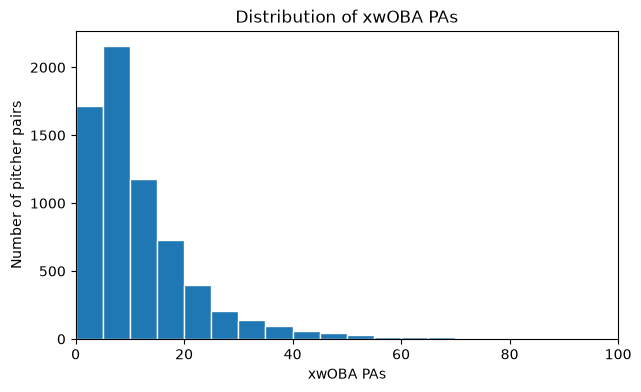

In [128]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7, 4))

plt.hist(
    pitcher_pairs["xwoba_pa"].dropna(),
    bins=np.arange(0, 105, 5),
    edgecolor="white"
)

plt.xlabel("xwOBA PAs")
plt.xlim(0, 100)
plt.ylabel("Number of pitcher pairs")
plt.title("Distribution of xwOBA PAs")

plt.show()

In [130]:
filtered_pairs = pitcher_pairs[
    pitcher_pairs["xwoba_pa"] >= 20
]

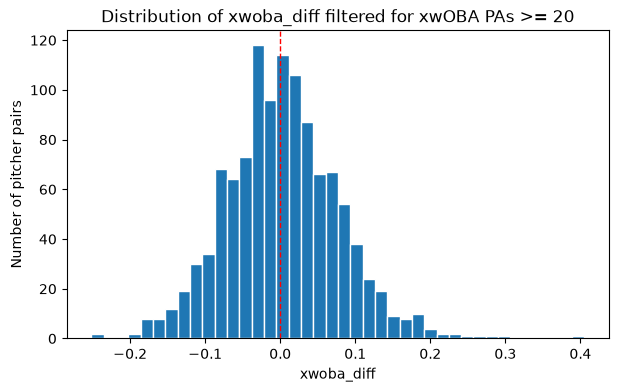

In [132]:
plt.figure(figsize=(7, 4))
plt.hist(filtered_pairs["xwoba_diff"].dropna(), bins=40, edgecolor="white")
plt.axvline(0, color="red", linestyle="--", linewidth=1)
plt.xlabel("xwoba_diff")
plt.ylabel("Number of pitcher pairs")
plt.title("Distribution of xwoba_diff filtered for xwOBA PAs >= 20")
plt.show()

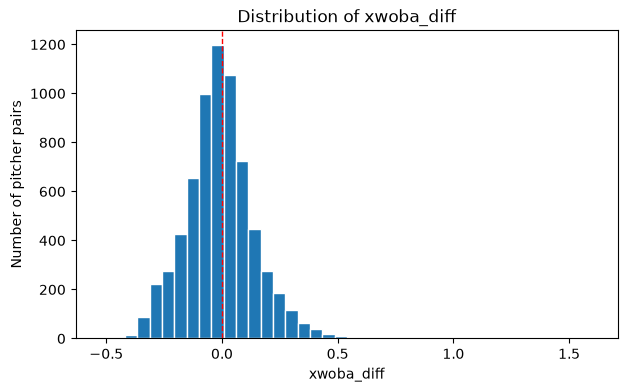

In [133]:
plt.figure(figsize=(7, 4))
plt.hist(pitcher_pairs["xwoba_diff"].dropna(), bins=40, edgecolor="white")
plt.axvline(0, color="red", linestyle="--", linewidth=1)
plt.xlabel("xwoba_diff")
plt.ylabel("Number of pitcher pairs")
plt.title("Distribution of xwoba_diff")
plt.show()

In [116]:
pitcher_pairs[pitcher_pairs['previous_pitcher_name'] == "Rogers, Tyler"]

,previous_pitcher,pitcher,xwoba_sum,xwoba_pa,appearances,pair_xwoba,total_xwoba_sum,total_xwoba_pa,other_xwoba,player_name,previous_pitcher_name,xwoba_diff
2168,643511.0,548384,3.196667,18,6,0.177593,23.880893,99,0.255361,"Raley, Brooks","Rogers, Tyler",-0.077768
2169,643511.0,592773,2.424000,4,1,0.606000,83.271402,255,0.322101,"Stanek, Ryne","Rogers, Tyler",0.283899
2170,643511.0,606965,1.003000,5,1,0.200600,19.481618,65,0.307977,"Devenski, Chris","Rogers, Tyler",-0.107377
2171,643511.0,621242,10.688430,35,8,0.305384,63.282120,256,0.237980,"Díaz, Edwin","Rogers, Tyler",0.067403
2172,643511.0,642397,1.429289,8,2,0.178661,84.080501,276,0.308400,"Soto, Gregory","Rogers, Tyler",-0.129739
2173,643511.0,657585,0.655889,3,1,0.218630,68.816264,236,0.292534,"Garrett, Reed","Rogers, Tyler",-0.073904
2174,643511.0,663855,3.176497,4,1,0.794124,102.059569,309,0.324207,"Hicks, Jordan","Rogers, Tyler",0.469917
2175,643511.0,663941,1.083000,7,2,0.154714,75.266312,231,0.331175,"Beck, Tristan","Rogers, Tyler",-0.176461
2176,643511.0,664192,0.780000,6,1,0.130000,47.492434,162,0.299439,"Lucchesi, Joey","Rogers, Tyler",-0.169439
2177,643511.0,664854,8.945988,22,5,0.406636,76.803673,248,0.300255,"Helsley, Ryan","Rogers, Tyler",0.106381


In [ ]:
previous_pitcher_effect = (
    pitcher_pairs[
        pitcher_pairs["previous_pitcher"].notna()
    ]
    .groupby(["previous_pitcher", "previous_pitcher_name"])
    .apply(
        lambda x: pd.Series({
            "weighted_xwoba_diff": (
                (x["xwoba_diff"] * x["xwoba_pa"]).sum()
                / x["xwoba_pa"].sum()
            ),
            "xwoba_pa": x["xwoba_pa"].sum(),
            "following_pitchers": x["pitcher"].nunique(),
            "pairs": len(x)
        }),
        include_groups=False
    )
    .reset_index()
)

In [119]:
previous_pitcher_effect.sort_values(by = 'weighted_xwoba_diff').head(20)

,previous_pitcher,previous_pitcher_name,weighted_xwoba_diff,xwoba_pa,following_pitchers,pairs
771,801216.0,"Montes De Oca, Christian",-0.504323,1.0,1.0,1.0
31,534910.0,"Hahn, Jesse",-0.350800,3.0,1.0,1.0
148,620443.0,"Torrens, Luis",-0.329136,2.0,1.0,1.0
135,608334.0,"Fulmer, Carson",-0.320115,5.0,2.0,2.0
204,641585.0,"France, J.P.",-0.319828,3.0,1.0,1.0
193,640454.0,"Krook, Matt",-0.299918,14.0,2.0,2.0
746,697812.0,"Rock, Joe",-0.288909,1.0,1.0,1.0
741,696131.0,"Black, Mason",-0.250784,3.0,1.0,1.0
69,592254.0,"De León, José",-0.237898,1.0,1.0,1.0
2,445926.0,"Chavez, Jesse",-0.231829,17.0,4.0,4.0


In [134]:
filt_previous_pitcher_effect = (
    filtered_pairs[
        filtered_pairs["previous_pitcher"].notna()
    ]
    .groupby(["previous_pitcher", "previous_pitcher_name"])
    .apply(
        lambda x: pd.Series({
            "weighted_xwoba_diff": (
                (x["xwoba_diff"] * x["xwoba_pa"]).sum()
                / x["xwoba_pa"].sum()
            ),
            "xwoba_pa": x["xwoba_pa"].sum(),
            "following_pitchers": x["pitcher"].nunique(),
            "pairs": len(x)
        }),
        include_groups=False
    )
    .reset_index()
)

In [135]:
filt_previous_pitcher_effect.sort_values(by = 'weighted_xwoba_diff').head(20)

,previous_pitcher,previous_pitcher_name,weighted_xwoba_diff,xwoba_pa,following_pitchers,pairs
304,677952.0,"Ashcraft, Braxton",-0.181043,20.0,1.0,1.0
156,656848.0,"Petersen, Michael",-0.166931,20.0,1.0,1.0
258,670329.0,"Garcia, Rico",-0.163313,50.0,2.0,2.0
208,665660.0,"Alvarado, Elvis",-0.160573,25.0,1.0,1.0
200,664123.0,"Effross, Scott",-0.137388,20.0,1.0,1.0
191,663767.0,"Shugart, Chase",-0.124995,26.0,1.0,1.0
345,683155.0,"Estes, Joey",-0.124544,24.0,1.0,1.0
404,695549.0,"Jobe, Jackson",-0.123753,30.0,1.0,1.0
7,489446.0,"Yates, Kirby",-0.121075,37.0,1.0,1.0
276,674285.0,"Salazar, Eduardo",-0.118824,29.0,1.0,1.0


In [137]:
filtered_pairs.sort_values(by = 'xwoba_diff').head(20)

,previous_pitcher,pitcher,xwoba_sum,xwoba_pa,appearances,pair_xwoba,total_xwoba_sum,total_xwoba_pa,other_xwoba,player_name,previous_pitcher_name,xwoba_diff
7008,NaN,688107,9.916985,29,2,0.341965,19.416383,45,0.593712,"Gasser, Robert",NaN,-0.251747
6703,NaN,477132,138.754631,458,22,0.302958,147.629009,474,0.554649,"Kershaw, Clayton",NaN,-0.251691
2131,643338.0,663893,3.014994,24,6,0.125625,95.207224,312,0.320112,"Little, Brendon","Green, Chad",-0.194487
6752,NaN,605483,99.898238,373,16,0.267824,102.635158,379,0.456153,"Snell, Blake",NaN,-0.188330
6950,NaN,680573,133.076867,450,22,0.295726,143.173087,471,0.480772,"Woods Richardson, Simeon",NaN,-0.185046
5239,681347.0,669387,3.331289,24,3,0.138804,129.163513,413,0.323476,"Mlodzinski, Carmen","Burrows, Mike",-0.184672
46,450203.0,672335,3.218289,20,3,0.160914,32.982327,107,0.342115,"Pérez, Cionel","Morton, Charlie",-0.181201
4862,677952.0,642701,2.489497,20,5,0.124475,78.563462,269,0.305518,"Santana, Dennis","Ashcraft, Braxton",-0.181043
4155,670329.0,700249,4.080491,22,1,0.185477,172.452708,484,0.364442,"Povich, Cade","Garcia, Rico",-0.178965
2346,656271.0,672282,3.575497,26,8,0.137519,77.527147,262,0.313354,"Detmers, Reid","Burke, Brock",-0.175835
